In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tabulate import tabulate

# Q3

In [2]:
def randomized_matrix_multiplication(A, B, r, seed_num=243):
    """
    Computes the product of two matrices A and B using randomized matrix multiplication.
    
    Parameters:
    A : numpy.ndarray
        The first input matrix of shape (m, n).
    B : numpy.ndarray
        The second input matrix of shape (n, p).
    r : int
        The number of random samples to take.
    seed_num : int, optional
        The seed for the random number generator. Default is 243.
    
    Returns:
    numpy.ndarray
        The approximate product of A and B of shape (m, p).
    """
    # set the random seed for reproducibility
    np.random.seed(seed_num)
    n = A.shape[1]
    
    # Calculate probabilities
    prob = np.array([np.linalg.norm(A[:, x], 2) * np.linalg.norm(B[x, :], 2) for x in range(n)])
    prob = prob / np.sum(prob)
    
    # Randomly sample columns of B and rows of A
    # and compute the outer product of A and B
    S = 0
    for i in range(r):
        l = np.random.choice(n, size=1, replace=True, p=prob)[0]
        S = S + np.outer(A[:, l], B[l, :]) / prob[l]
    
    S = S / r
    
    return S

     r     error
0   20  0.190787
1   50  0.128489
2  100  0.095043
3  200  0.074441


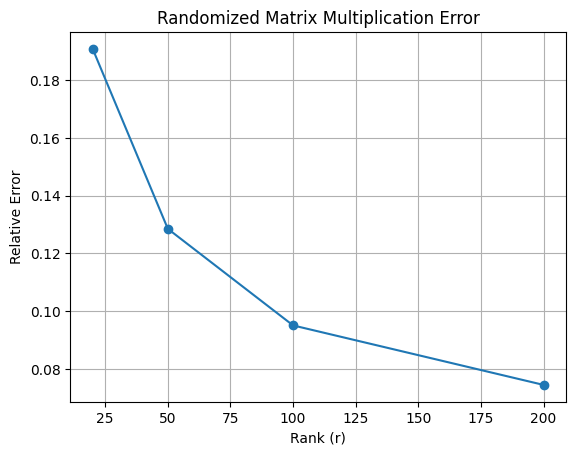

In [3]:
# Read matrices from CSV files
A = np.array(pd.read_csv("STA243_homework_1_matrix_A.csv", header=None))
B = np.array(pd.read_csv("STA243_homework_1_matrix_B.csv", header=None))
C = np.matmul(A, B)# Matrix multiplication

# Perform randomized matrix multiplication with different ranks and calculate errors
result_rmm = []
result_error = []
r_vec = [20, 50, 100, 200]

for r in r_vec:
    # Perform randomized matrix multiplication
    # The function randomized_matrix_multiplication is used to perform the multiplication
    M = randomized_matrix_multiplication(A, B, r)
    # Calculate error
    # The error is defined as the Frobenius norm of the difference between the true product and the estimated product
    error = np.linalg.norm(M - C, 'fro') / (np.linalg.norm(A, 'fro') * np.linalg.norm(B, 'fro'))
    result_rmm.append(M)
    result_error.append(error)

# Print results
print(pd.DataFrame({'r': r_vec, 'error': result_error}))
# Plot results
plt.plot(r_vec, result_error, marker='o')
plt.xlabel('Rank (r)')
plt.ylabel('Relative Error')
plt.title('Randomized Matrix Multiplication Error')
plt.grid()
plt.show()

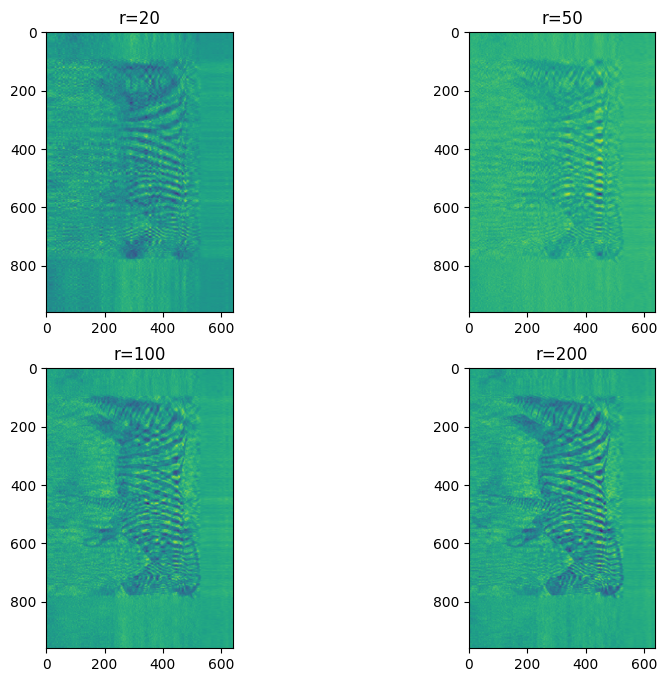

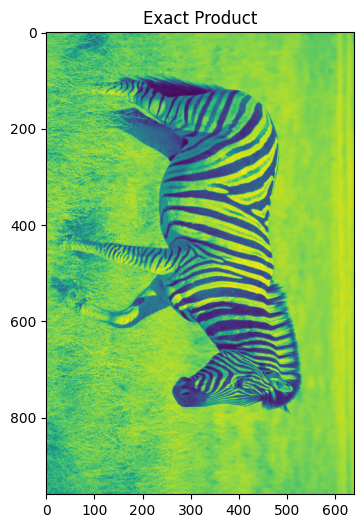

In [4]:
# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i, r in enumerate(r_vec):
    axs[i].imshow(result_rmm[i])
    axs[i].set_title(f"r={r}")

plt.show()

# Display the exact product
plt.figure(figsize=(6, 6))
plt.imshow(C, cmap='viridis')
plt.title("Exact Product")
plt.show()

# Q4

In [5]:
def power_iteration(A, v0, eps=1e-6, maxiter=100, num_trunc=None):
    """
    Implement the power iteration algorithm to find the dominant eigenvector of a matrix.
    
    Parameters:
        :param A (numpy.ndarray): The input matrix
        :param v0 (numpy.ndarray): Initial guess for the eigenvector
        :param eps (float): Convergence criterion
        :param maxiter (int): Maximum number of iterations
        :param num_trunc (int): Number of components to keep (truncation parameter)
 
    Returns:
        numpy.ndarray: The estimated eigenvector
    """
    
    c_old = v0
    step = 0
    while step < maxiter:
        # Normalize the vector
        c = np.dot(A, c_old)
        c = c / np.linalg.norm(c)
        
        if num_trunc is not None:
            # Get the indices that would sort c in descending order
            indices = np.argsort(-np.abs(c))
            # Zero out all except the top num_trunc elements
            mask = np.zeros_like(c, dtype=bool)
            mask[indices[:num_trunc]] = True
            c[~mask] = 0
            # Normalize again
            if np.linalg.norm(c) > 0:  # Avoid division by zero
                c = c / np.linalg.norm(c)
        
        crit = np.linalg.norm(c - c_old)
        if crit < eps:
            break
        else:
            c_old = c
            step += 1
    
    if step == maxiter:
        print(f"The optimal value does not converge at max iteration = {maxiter}")
    
    return c

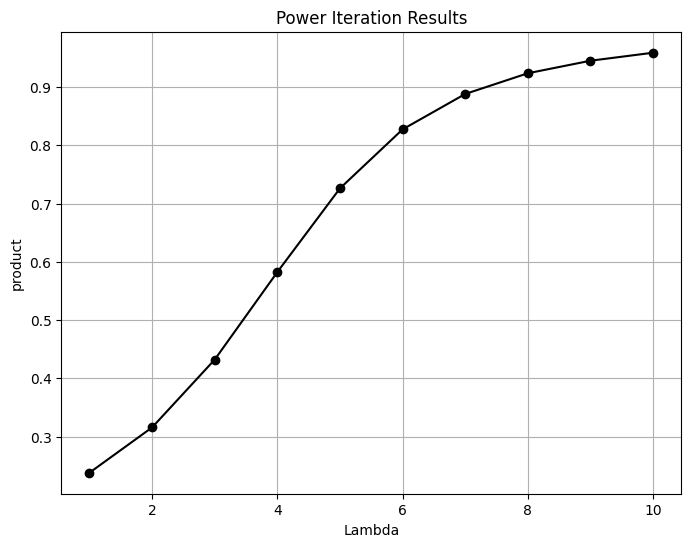

In [6]:
# Set random seed for reproducibility
np.random.seed(2022)

# Create a random 10x10 matrix
E = np.random.randn(10, 10)

# Create a vector with 1 followed by nine 0's
v = np.array([1] + [0] * 9)

# Range of lambda values
lams = np.arange(1, 11)

# List to store products
prods = []

# Iterate over lambda values
for lambda_ in lams:
    # Create matrix X
    X = lambda_ * np.outer(v, v) + E
    
    # Initialize v0 as a normalized vector of ones
    v0 = np.ones(E.shape[0])
    v0 = v0 / np.linalg.norm(v0)
    
    # Run power iteration
    vv = power_iteration(X, v0, maxiter=10000)

    # Compute and store the absolute dot product
    prods.append(abs(np.dot(v, vv)))

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(lams, prods, '-ok')
plt.xlabel('Lambda')
plt.ylabel('product')
plt.title('Power Iteration Results')
plt.grid(True)
plt.show()

# Q5

In [7]:
def fhm(x):
    """
    Fast Hadamard Transform implementation.
    """
    n = len(x)
    
    # Check if n is a power of 2
    original_n = n
    if n & (n - 1) != 0:
        # If not, pad with zeros
        next_power = 2 ** np.ceil(np.log2(n)).astype(int)
        x_padded = np.zeros(next_power)
        x_padded[:n] = x
        x = x_padded
        n = next_power
    
    # Create a copy of the input array
    y = x.copy()
    
    # In-place Fast Hadamard Transform
    h = 1
    while h < n:
        for i in range(0, n, 2 * h):
            for j in range(i, i + h):
                if j + h < n:  # Ensure we don't go out of bounds
                    u = y[j]
                    v = y[j + h]
                    y[j] = u + v
                    y[j + h] = u - v
        h *= 2
    
    # Return only the first original_n elements if padding was applied
    return y[:original_n] / np.sqrt(n)

def phi_generate(X, y, e=0.1, seed_num=243):
    """
    Implementation of phi_generate function
    """
    np.random.seed(seed_num)
    n, d = X.shape
    r = int(round(d * np.log(n) / e))
    
    # Sample D from {-1, 1} with equal probability
    D = np.random.choice([1, -1], size=n, replace=True, p=[0.5, 0.5])
    
    # Apply D to each column of X and to y
    DX = D[:, np.newaxis] * X
    Dy = D * y
    
    # Apply fhm to each column of DX and to Dy
    HDX = np.apply_along_axis(fhm, 0, DX)
    HDy = fhm(Dy)
    
    # Sample indices with replacement
    index = np.random.choice(n, size=r, replace=True)
    
    # Apply transformation to create X2 and y2
    X2 = np.zeros((r, d))
    for j in range(d):
        X2[:, j] = np.sqrt(n/r) * HDX[index, j]
    
    y2 = np.sqrt(n/r) * HDy[index]
    
    return {'X': X2, 'y': y2}

In [8]:
# Set random seed
np.random.seed(143)

# Create random matrices
x = np.random.rand(1048576, 20)
y = np.random.rand(1048576)

# Measure time for OLS computation
start_time = time.time()
beta_ols = np.linalg.solve(np.dot(x.T, x), np.dot(x.T, y))
time_ols = time.time() - start_time

# List of epsilon values
e_list = [0.1, 0.05, 0.01, 0.001]

# Create result dataframe
out = pd.DataFrame(index=range(len(e_list)))
out["Epsilon"] = e_list
out["Computation Time"] = None

# Loop through epsilon values
for i, e in enumerate(e_list):
    phi = phi_generate(x, y, e)
    
    start_time = time.time()
    b_fast = np.linalg.solve(np.dot(phi['X'].T, phi['X']), np.dot(phi['X'].T, phi['y']))
    time_fast = time.time() - start_time
    
    out.loc[i, "Computation Time"] = time_fast

# Add OLS time to the last row
out=pd.concat([out,pd.DataFrame([['OLS', time_ols]],columns=out.columns)], ignore_index=True)

# Display result
print(tabulate(out, headers='keys', tablefmt='pipe', showindex=False))

| Epsilon   |   Computation Time |
|:----------|-------------------:|
| 0.1       |        0.000253916 |
| 0.05      |        0.000325203 |
| 0.01      |        0.00128531  |
| 0.001     |        0.00987411  |
| OLS       |        0.0443492   |
